# 09 - DCA and leverage risk

Use the promoted live champion on its default core symbols. Simulate depositing `$1000` at the start, then `$200` at the start of each following month. Then scale the strategy return stream by several leverage multipliers and inspect ending equity, drawdowns, and simple liquidation-risk proxies.

This is an approximation: the harness itself is still unlevered/cash-sharing. Leverage here means `account_return = leverage * strategy_return` applied to the realized 4h portfolio return stream, with monthly cash contributions added after that bar's return.

In [1]:
import json
import sys; sys.path.insert(0, ".")
from _lab import *

symbols = list(strategy.DEFAULT_SYMBOLS)
start, end = "2024-01-01", "2026-01-01"
initial_deposit = 1000.0
monthly_deposit = 200.0

result = run_pair(symbols, start, end, return_curves=True)
curves = result["curves"]
base_equity = curves["equity"].astype(float)
base_returns = base_equity.pct_change().fillna(0.0)

print("symbols:", symbols)
metrics_frame(result)

symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']


,sharpe,sortino,max_dd,total_return,n_trades,pct_time_in_position,profit_factor
split,,,,,,,
train,2.430799,3.262376,0.086778,1.054048,370,60.060790,1.565904
oos,0.376599,0.439049,0.100273,0.029942,124,62.591241,1.056940


In [2]:
def monthly_contributions(index, initial=1000.0, monthly=200.0):
    contrib = pd.Series(0.0, index=index)
    contrib.iloc[0] += initial
    months = pd.date_range(index[0].normalize(), index[-1].normalize(), freq="MS", tz="UTC")
    for m in months[1:]:
        loc = index.searchsorted(m)
        if loc < len(index):
            contrib.iloc[loc] += monthly
    return contrib

def simulate_dca(returns, leverage=1.0, initial=1000.0, monthly=200.0):
    contrib = monthly_contributions(returns.index, initial, monthly)
    eq = pd.Series(index=returns.index, dtype=float)
    liquidated = False
    liq_time = pd.NaT
    value = 0.0
    for i, (ts, r) in enumerate(returns.items()):
        if liquidated:
            value = max(0.0, value) + float(contrib.iloc[i])
            eq.iloc[i] = value
            continue
        value *= 1.0 + leverage * float(r)
        value += float(contrib.iloc[i])
        if value <= 0.0:
            liquidated = True
            liq_time = ts
            value = 0.0
        eq.iloc[i] = value
    return eq, contrib, liquidated, liq_time

def xirr_like_cash_return(equity, contrib):
    total_contrib = contrib.sum()
    return equity.iloc[-1] / total_contrib - 1.0

def summarize_leverage(returns, lev):
    eq, contrib, liquidated, liq_time = simulate_dca(returns, lev, initial_deposit, monthly_deposit)
    dd = drawdown(eq)
    scaled_ret = lev * returns
    # A single-bar account wipeout happens if 1 + lev*r <= 0.
    one_bar_wipe = bool((scaled_ret <= -1.0).any())
    worst_bar = float(scaled_ret.min())
    return {
        "leverage": lev,
        "total_contributed": float(contrib.sum()),
        "ending_equity": float(eq.iloc[-1]),
        "profit_vs_contrib": float(eq.iloc[-1] - contrib.sum()),
        "return_on_contrib": float(xirr_like_cash_return(eq, contrib)),
        "max_drawdown": float(dd.min()),
        "min_equity": float(eq.min()),
        "worst_4h_return": worst_bar,
        "one_bar_wipeout": one_bar_wipe,
        "liquidated": bool(liquidated),
        "liq_time": str(liq_time) if pd.notna(liq_time) else None,
    }

leverages = [1, 1.5, 2, 2.5, 3, 4, 5, 7.5, 10]
sims = {}
rows = []
for lev in leverages:
    eq, contrib, liquidated, liq_time = simulate_dca(base_returns, lev, initial_deposit, monthly_deposit)
    sims[lev] = {"equity": eq, "contrib": contrib, "liquidated": liquidated, "liq_time": liq_time}
    rows.append(summarize_leverage(base_returns, lev))
summary = pd.DataFrame(rows).set_index("leverage")
summary

,total_contributed,ending_equity,profit_vs_contrib,return_on_contrib,max_drawdown,min_equity,worst_4h_return,one_bar_wipeout,liquidated,liq_time
leverage,,,,,,,,,,
1.0,5600.0,8391.146323,2791.146323,0.498419,-0.086778,930.932358,-0.032489,False,False,None
1.5,5600.0,10330.808466,4730.808466,0.844787,-0.127764,897.845205,-0.048734,False,False,None
2.0,5600.0,12719.824093,7119.824093,1.271397,-0.167209,865.694853,-0.064979,False,False,None
2.5,5600.0,15619.783969,10019.783969,1.789247,-0.216973,834.460961,-0.081223,False,False,None
3.0,5600.0,19082.134826,13482.134826,2.407524,-0.265403,804.123498,-0.097468,False,False,None
4.0,5600.0,27802.726263,22202.726263,3.964773,-0.353843,746.059265,-0.129957,False,False,None
5.0,5600.0,38791.897268,33191.897268,5.927125,-0.432882,691.348015,-0.162446,False,False,None
7.5,5600.0,69737.753555,64137.753555,11.453170,-0.597456,568.270787,-0.243670,False,False,None
10.0,5600.0,83384.989407,77784.989407,13.890177,-0.722869,463.023563,-0.324893,False,False,None


[saved] notebooks\volume_weighted_breakout\_out\09_dca_leverage_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/09_dca_leverage_equity_drawdown.png')

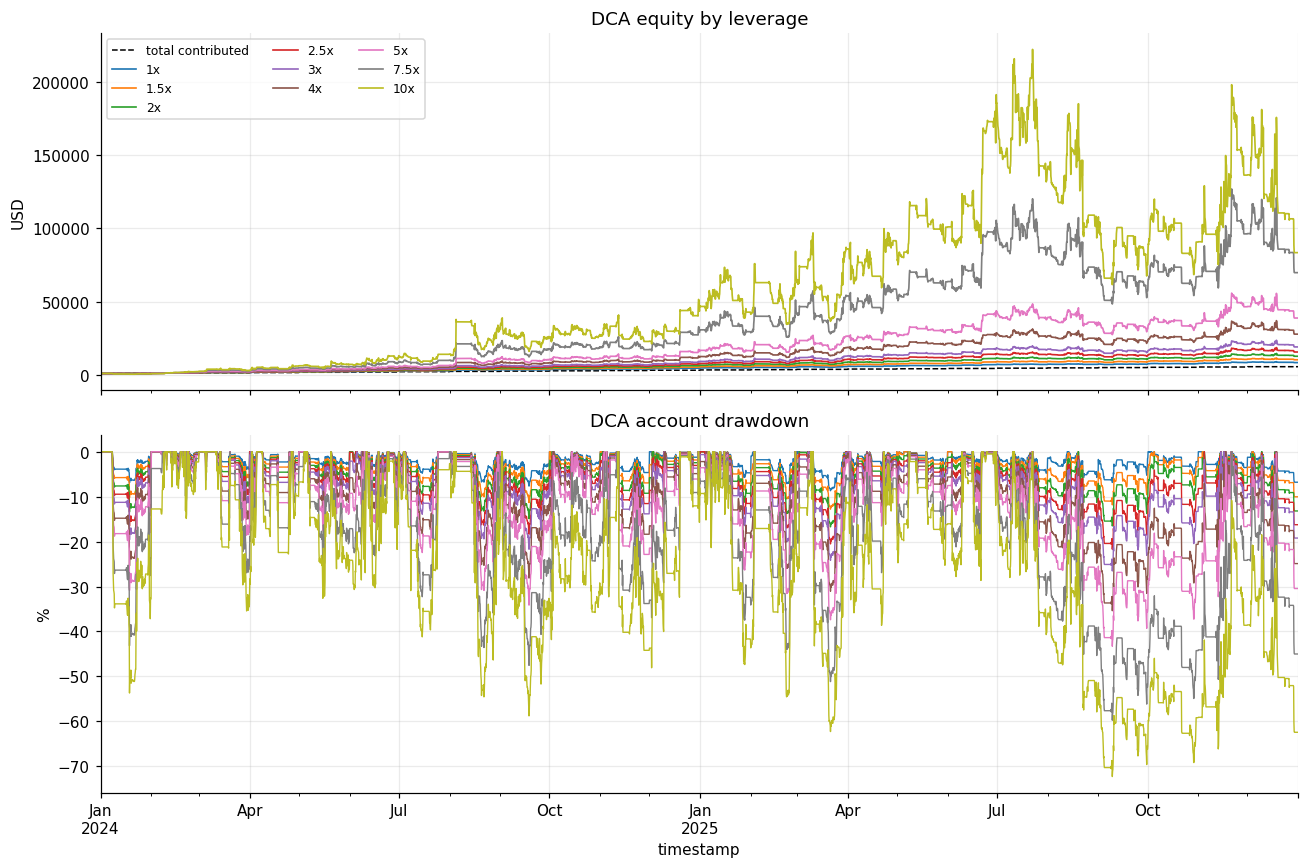

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
cum_contrib = sims[1]["contrib"].cumsum()
cum_contrib.plot(ax=ax[0], color="k", ls="--", lw=1.0, label="total contributed")
for lev in leverages:
    sims[lev]["equity"].plot(ax=ax[0], lw=1.1, label=f"{lev:g}x")
    (drawdown(sims[lev]["equity"]) * 100).plot(ax=ax[1], lw=0.9, label=f"{lev:g}x")
ax[0].set_title("DCA equity by leverage")
ax[0].set_ylabel("USD")
ax[0].legend(ncol=3, fontsize=8)
ax[1].set_title("DCA account drawdown")
ax[1].set_ylabel("%")
show("09_dca_leverage_equity_drawdown")

[saved] notebooks\volume_weighted_breakout\_out\09_dca_leverage_metric_bars.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/09_dca_leverage_metric_bars.png')

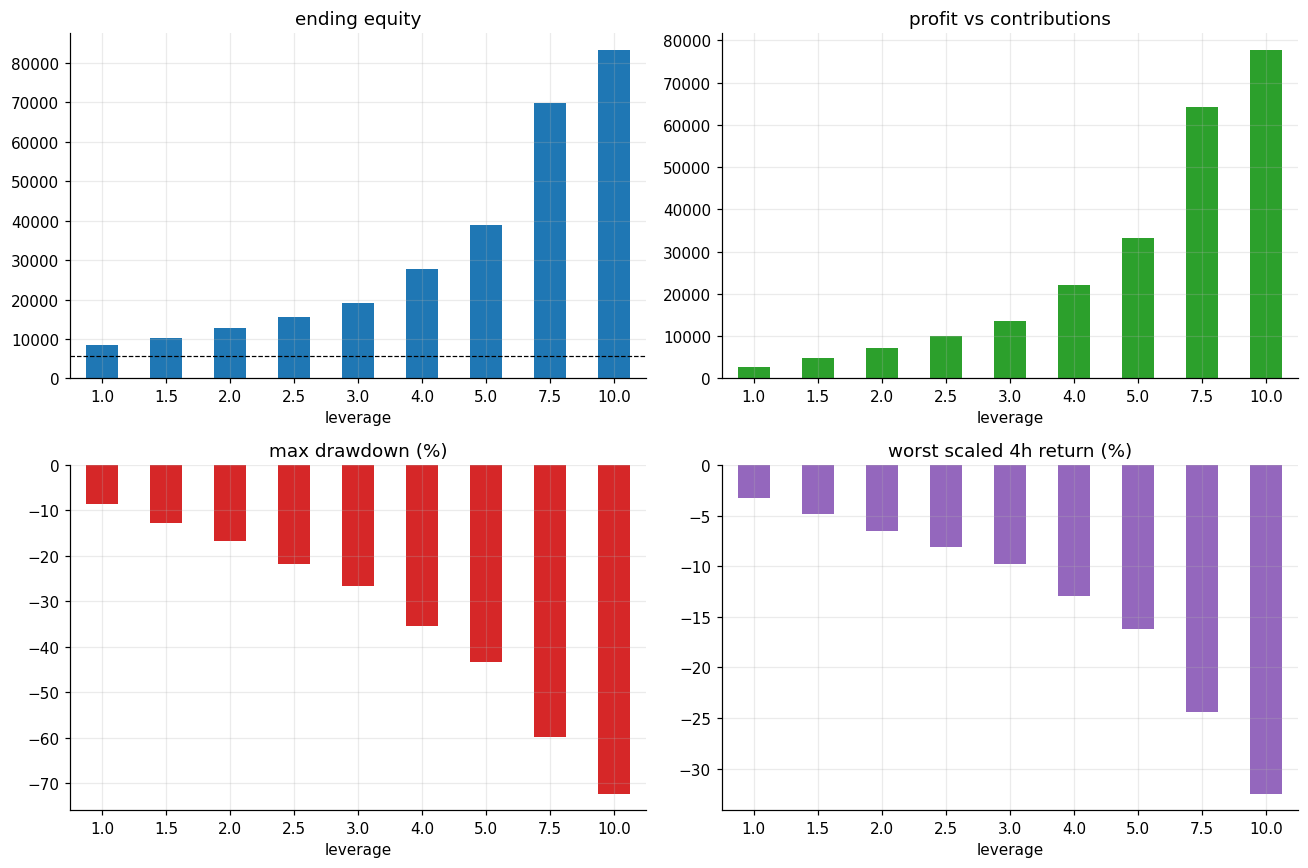

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
summary["ending_equity"].plot(kind="bar", ax=ax[0,0], color="C0")
ax[0,0].axhline(summary.loc[1, "total_contributed"], color="k", ls="--", lw=0.8)
ax[0,0].set_title("ending equity")
summary["profit_vs_contrib"].plot(kind="bar", ax=ax[0,1], color=np.where(summary["profit_vs_contrib"] >= 0, "C2", "C3"))
ax[0,1].set_title("profit vs contributions")
(summary["max_drawdown"] * 100).plot(kind="bar", ax=ax[1,0], color="C3")
ax[1,0].set_title("max drawdown (%)")
(summary["worst_4h_return"] * 100).plot(kind="bar", ax=ax[1,1], color="C4")
ax[1,1].set_title("worst scaled 4h return (%)")
for axis in ax.ravel():
    axis.tick_params(axis="x", rotation=0)
show("09_dca_leverage_metric_bars")

In [5]:
# Liquidation proxy from observed path.
# Approximate isolated account liquidation threshold for leverage L is near -1/L
# before maintenance margin. We compare observed peak-to-trough account DD and
# worst 4h scaled loss to that crude threshold.
liq_rows = []
for lev in leverages:
    threshold = -1.0 / lev
    liq_rows.append({
        "leverage": lev,
        "approx_liq_move": threshold,
        "observed_max_dd": summary.loc[lev, "max_drawdown"],
        "observed_worst_4h": summary.loc[lev, "worst_4h_return"],
        "dd_buffer_to_liq": threshold - summary.loc[lev, "max_drawdown"],
        "one_bar_buffer_to_liq": threshold - summary.loc[lev, "worst_4h_return"],
        "path_liquidated": summary.loc[lev, "liquidated"],
        "one_bar_wipeout": summary.loc[lev, "one_bar_wipeout"],
    })
liq = pd.DataFrame(liq_rows).set_index("leverage")
liq

,approx_liq_move,observed_max_dd,observed_worst_4h,dd_buffer_to_liq,one_bar_buffer_to_liq,path_liquidated,one_bar_wipeout
leverage,,,,,,,
1.0,-1.000000,-0.086778,-0.032489,-0.913222,-0.967511,False,False
1.5,-0.666667,-0.127764,-0.048734,-0.538902,-0.617933,False,False
2.0,-0.500000,-0.167209,-0.064979,-0.332791,-0.435021,False,False
2.5,-0.400000,-0.216973,-0.081223,-0.183027,-0.318777,False,False
3.0,-0.333333,-0.265403,-0.097468,-0.067930,-0.235865,False,False
4.0,-0.250000,-0.353843,-0.129957,0.103843,-0.120043,False,False
5.0,-0.200000,-0.432882,-0.162446,0.232882,-0.037554,False,False
7.5,-0.133333,-0.597456,-0.243670,0.464122,0.110336,False,False
10.0,-0.100000,-0.722869,-0.324893,0.622869,0.224893,False,False


In [6]:
# Show the worst drawdown windows for plausible leverage choices.
for lev in [1, 2, 3, 4, 5]:
    eq = sims[lev]["equity"]
    dd = drawdown(eq)
    trough = dd.idxmin()
    peak = eq.loc[:trough].idxmax()
    print(f"{lev:g}x: worst DD {dd.loc[trough]:.2%}, peak {peak}, trough {trough}, equity {eq.loc[peak]:.2f}->{eq.loc[trough]:.2f}")

1x: worst DD -8.68%, peak 2025-03-10 20:00:00+00:00, trough 2025-03-21 12:00:00+00:00, equity 5726.77->5229.81
2x: worst DD -16.72%, peak 2025-03-10 20:00:00+00:00, trough 2025-03-21 12:00:00+00:00, equity 8636.74->7192.60
3x: worst DD -26.54%, peak 2025-07-22 20:00:00+00:00, trough 2025-09-09 12:00:00+00:00, equity 19735.08->14497.32
4x: worst DD -35.38%, peak 2025-07-22 20:00:00+00:00, trough 2025-09-09 12:00:00+00:00, equity 31396.28->20286.93
5x: worst DD -43.29%, peak 2025-07-22 20:00:00+00:00, trough 2025-09-09 12:00:00+00:00, equity 48439.80->27471.08


In [7]:
# Monthly view for the unlevered DCA case.
eq1 = sims[1]["equity"]
monthly = pd.DataFrame({
    "contribution": sims[1]["contrib"].resample("ME").sum(),
    "ending_equity": eq1.resample("ME").last(),
})
monthly["profit_vs_contrib_to_date"] = monthly["ending_equity"] - monthly["contribution"].cumsum()
monthly

,contribution,ending_equity,profit_vs_contrib_to_date
timestamp,,,
2024-01-31 00:00:00+00:00,1000.0,972.988098,-27.011902
2024-02-29 00:00:00+00:00,200.0,1301.066154,101.066154
2024-03-31 00:00:00+00:00,200.0,1552.388243,152.388243
2024-04-30 00:00:00+00:00,200.0,1892.395985,292.395985
2024-05-31 00:00:00+00:00,200.0,2143.830408,343.830408
2024-06-30 00:00:00+00:00,200.0,2513.979873,513.979873
2024-07-31 00:00:00+00:00,200.0,2767.236432,567.236432
2024-08-31 00:00:00+00:00,200.0,3351.091342,951.091342
2024-09-30 00:00:00+00:00,200.0,3519.012787,919.012787
